# Case 8: Hypothesis testing I

## *Do there exist significant differences between the balances of my various customers' cohorts?*

## Goals (3 min)

One of the key problems in data science is assessing whether a pattern you notice is 
- a pattern inherent in the overall population from which the observations are drawn
- a spurious pattern specific to the sample of observations you have 

In this case, you will learn a fundamental tool to approach this problem called **statistical hypothesis testing**. By the end of this case, you should know how to conduct a hypothesis test, analyze its outcome, and identify its shortcomings.

## Introduction (5 min)

**Business Context.** You are leading a business analytics unit in a bank and have been asked to support the marketing unit to conduct a customer segmentation analysis. You are provided with a dataset comprising a sample of customers, their bank account balances, and some demographic information about them. Different populations across the country have different income levels and may have different spending profiles. Your marketing team wants to know if there are significant differences in the bank balances of different subsegments of your customer base, so that they can design targeted products for different groups. 

**Business problem.** The marketing department wants you to determine: **"Do there exist statistically significant differences in the bank balances of your customer segments (by age, job, education, marital status, etc.)?"** 

**Analytical Context.** The dataset that we will use in this case was retrieved from Kaggle (https://www.kaggle.com/skverma875/bank-marketing-dataset). In this case, we will take the first step towards transitioning from **exploratory data analysis** to **confirmatory analysis** or **statistical inference**. We will: (1) learn a formal framework for hypothesis testing; (2) learn about $p$ - values; (3) generate a hypothesis from exploratory data analysis; and finally (4) analyze the results of a hypothesis test.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels
from scipy import stats 
from pingouin import pairwise_tests #this is for performing the pairwise tests
from pingouin import pairwise_ttests #this is for performing the pairwise tests

## Data Exploration (15 min)

The data includes the account balance of 45,211 customers, along with several other characteristics:

In [2]:
bank = pd.read_csv("bank-full.csv")
bank.shape

(45211, 17)

In [3]:
bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


The relevant features we will use in this case are:

1. **balance:** bank balance; key variable of interest
2. **job:** the title of the job (“management”, “technician”, etc)
3. **marital:** marital status ("single", "married" or "divorced")
4. **education:** different levels of education ("primary","secondary","tertiary","unknown")
5. **default:** the customer defaulted ("yes" or "no")
6. **loan:** the customer took out a loan ("yes" or "no")

In [4]:
bank.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


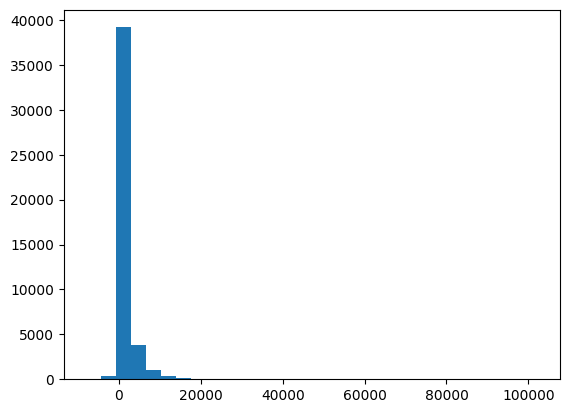

In [5]:
plt.hist(bank['balance'],bins = 30);

(-2500.0, 20000.0)

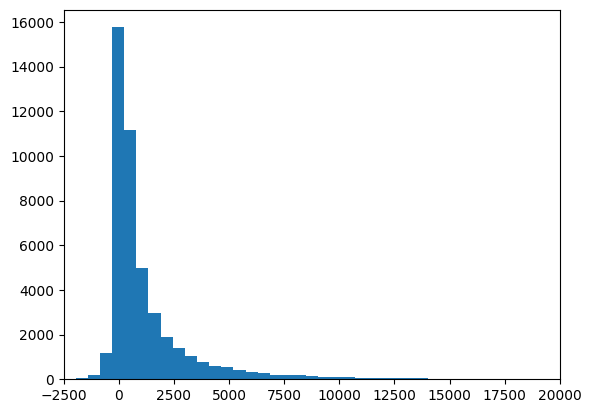

In [6]:
plt.hist(bank['balance'],bins = 200);
plt.xlim((-2500,20000))

### Exercise 1: (3 min)

From the tables and histogram above, we see a huge range in the bank balance of your customers. Why do you think this is?

**Answer.** Very often, a wide range in the outcome of interest of a population indicates the existence of several subgroups in the population. In our case, there are people with varying degrees of education, job profiles, etc. We will expect these subgroups to have different bank balances.

Let us understand our data further by plotting the variables. Consider the variables `job`, `marital`, `education`, `default`, `housing`, `loan`. For each of these variables, we plot the number of customers in each category as follows.

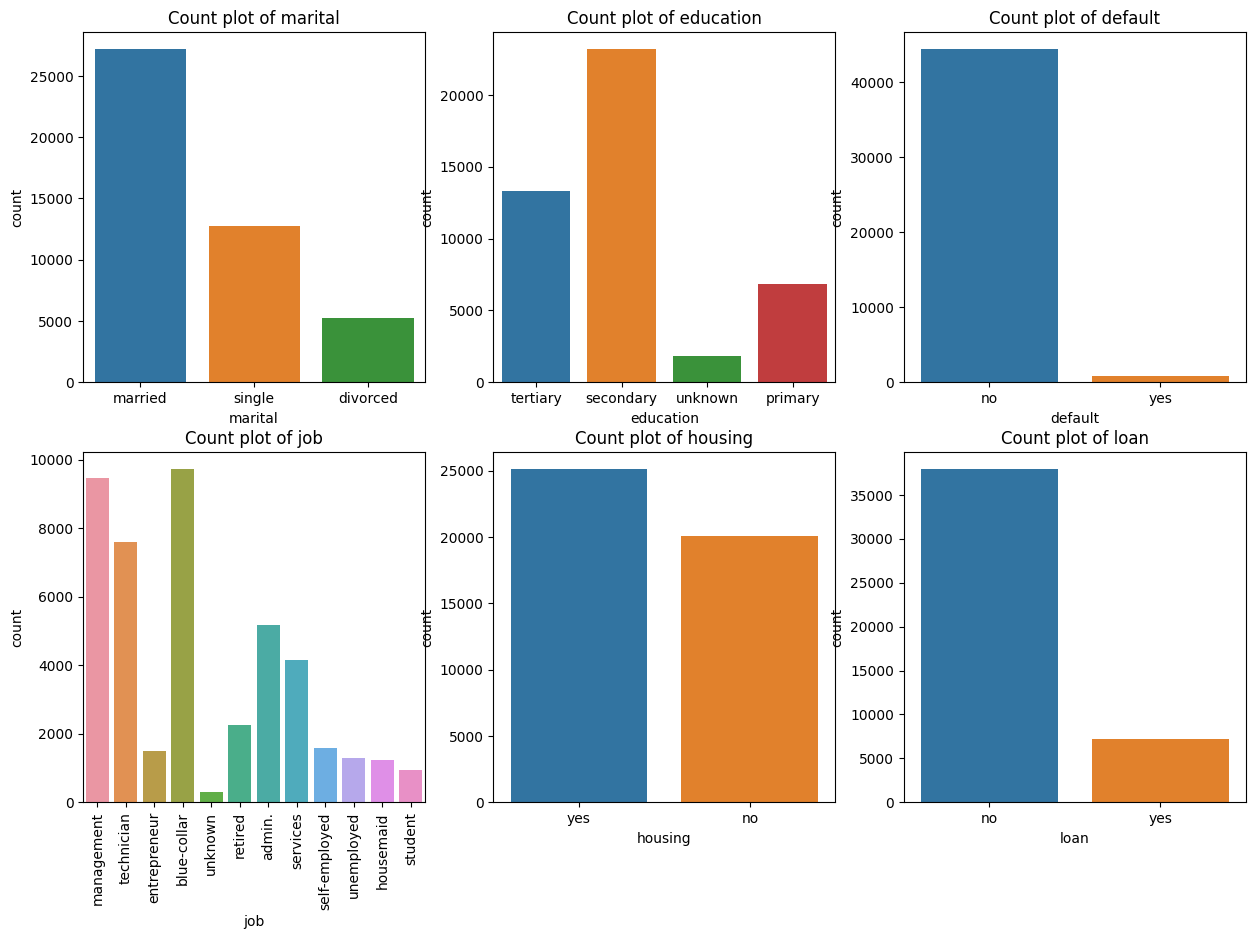

In [7]:
plt.figure(figsize=(15,10))
vars_to_look = ['marital','education','default','job','housing','loan']
for i, var in enumerate(vars_to_look):
    plt.subplot(2,3,i+1)
    if i ==3:
        plt.xticks(rotation = 90)
    sns.countplot(x=bank[var])
    plt.title("Count plot of " + var)    

### Exercise 2: (3 min)

What can you conclude from the plots? 

**Answer.** We confirm our initial guess - there exists a variation across the different categories, thus we may suspect that these differences are key to understanding the variation of the bank balances. 

### Exercise 3: (3 min)

Last year the average balance for the entire population of the bank's customers was \\$1341.12. How much higher is the sample average balance this year? Is this difference statistically significant?

**Answer.**

In [8]:
print(bank['balance'].mean())
round(bank['balance'].mean()-1341.12,2)

1362.2720576850766


21.15

This is a difference of \\$1362.27 - \\$1341.12 = \\$21.15. The bank management thinks that the consumer behavior might have changed slightly, and that, on average, customers are keeping more money in their bank account.

However, this difference might be due to statistical variation because of sampling variability. We would need to conduct a more rigorous analysis to determine if this difference is actually "significant", i.e., signifies a change in the population characterisitcs, after factoring in such variability.

**We know they should be different due to natural variations and randomness. The question is then *Is this difference within the expected amount of randomness?***

## Analytical framework for hypothesis testing (20 min)

The procedure that we use to help us decide whether a difference between the mean $\mu$ of a population and a reference value $\mu_0$ is **statistically significant** is called **hypothesis testing**. In our context,
$\mu$ is the average bank balance of the customers this year and $\mu_0$ is their average bank balance last year.

The first step is defining the null hypothesis (often indicated as $H_0$). For us, the null hypothesis will **always** correspond to the hypothesis of no change; that is, the status quo is still valid. Formally, this is written as: $ H_0: \mu = \mu_0 $.

In our case, $H_0$ would be equivalent in hypothesizing that the average balance for the entire customer population $\mu$ is the same as the average balance last year $\mu_0 = \$1341.12$. We wish to test if $H_0$ is wrong; that is, if $\mu$ is different from $\mu_0 = \$1341.12$.


### Alternative Hypothesis (3 min)

In opposition to the null hypothesis, we define an alternative hypothesis (often indicated with $H_1$ or $H_a$) to challenge the status quo. We can have three different ways to define an alternative hypothesis:

1. $H_a: \mu \neq \mu_0$ (two-sided test)

2. $H_a: \mu > \mu_0$ (one-sided test)

3. $H_a: \mu < \mu_0$ (one-sided test)

The statistical test will help us decide if there is enough evidence to reject the null hypothesis in favor of an alternative.

### Conducting a hypothesis test (3 min)

Returning to our case, suppose we wish to perform a statistical test to assess the hypothesis of management:

$$ H_0: \mu= 1341.12$$
$$ H_a: \mu > 1341.12$$

There are two possible outcomes for this test: 
- (1) We conclude $H_0$ is false, and say we **reject $H_0$**. In this case we will conclude that there is statistical evidence for the alternative $H_a$ and that the bank balance of customers this year is indeed greater than 1341.12 USD. 
- Or (2) we **fail to reject $H_0$**. In this case, we conclude that there is not enough statistical evidence to say that $H_0$ is false. 
- **Notice that in the second case we cannot say that the original hypothesis is true.** (In fact, there is no test out there that will tell you that a hypothesis is true. Why do you think that is?)

We can use [Student's](https://www.guinness-storehouse.com/content/pdf/archive-factsheets/general-history/wsgosset-and-students-t-test.pdf) $t$-[test](https://en.wikipedia.org/wiki/Student's_t-test) to conduct a hypothesis test for the mean parameter of single population. Note this is in reference to the theoretical population mean and NOT the sample mean. The following command lets us run this test:

In [9]:
r=np.random.standard_normal(10000000)*100+1342
print(stats.ttest_1samp(r, popmean=1341.122,alternative='greater'))
# np.mean(r)-1341.122

TtestResult(statistic=28.649846666967296, pvalue=8.187651016777481e-181, df=9999999)


In [10]:
print(stats.ttest_1samp(bank['balance'], popmean=1341.122,alternative='greater'))

TtestResult(statistic=1.4769973489267905, pvalue=0.06984165666422609, df=45210)


If instead: 
$$ H_0: \mu= 1341.12$$
$$ H_a: \mu \neq  1341.12$$


In [11]:
#If instead, we had \mu\neq 1341.122 we would run
print(stats.ttest_1samp(bank['balance'], popmean=1341.122))

TtestResult(statistic=1.4769973489267905, pvalue=0.13968331332845219, df=45210)


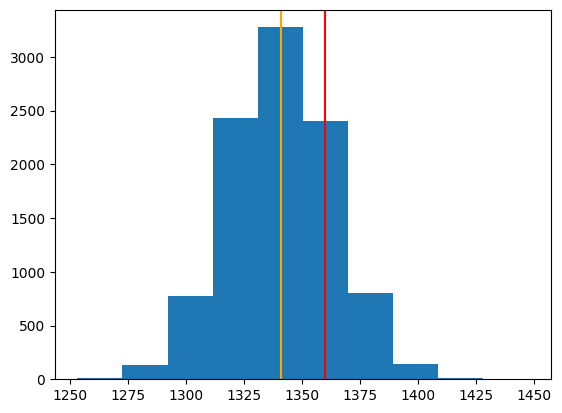

In [12]:
means=np.array([])

for i in range(0,10000):
    # sample 20 observations from a population where mu is 1341
    r=np.random.standard_normal(20)*100+1341
    mean_i=np.mean(r)
    means=np.append(means,mean_i)

plt.hist(means)
plt.axvline(x=1341,color='orange')
plt.axvline(x=1360,color='red')
# plt.axvline(x=1341-(1380-1341),color='red')

### Reading the output of a statistical test: $p$ - values (8 min)

Statistical tests report two quantities, a test statistic and a **$p$ - value**. 

- The p-value is the **key quantity that measures evidence against the null hypothesis.** The $p$ - value can be interpreted as follows: **Under the assumption that the null hypothesis is true, the $p$ - value is the probability we drew a sample which produced a test statistic at least as extreme as the one we observed. 

- The test statistic is a quantity computed from the sample which is related to the type of hypothesis test we are completed. For instance, in this case the test statistic is $\sqrt{n-1}(\bar{X}-1341.12)/\hat{\sigma}$

- In this case, if the population mean bank balance did not change, there was a 7\% chance we saw a test statistic as large as 1.48. There was a 14\% chance we saw a test statistic as extreme (positive or negative) as 1.48.

- Smaller p-values indicate stronger evidence against the null hypothesis. Small $p$-values imply that if the null was true, then it was very unlikely we saw the sample we saw. 

In a formal hypothesis test, people define a threshold $\alpha$, called the significance level. 
If the $p$-value is larger than $\alpha$, we would reject the null hypothesis; saying that there is strong evidence against the null hypothesis. In general, $\alpha$ should be chosen based on context, the most common thing to do is to set $\alpha=0.05$ (which of course, has some drawbacks). 

We can have two outcomes:

1. If this probability is smaller than our significance level ($p < \alpha$) we reject $H_0$ and we claim that the observed difference is "statistically significant".
2. If this probability is greater than our significance level ($p > \alpha$) we have to retain $H_0$ and we claim that the observed difference is not statistically significant.

**If $H_0$ is rejected it DOESN'T mean that the probability of $H_a$ is 1-($p$ - value)**

### Question: (2 min)

What do you conclude from the output? Do we reject $H_0$?

**Answer.** Since the $p$ - value (0.0698) is larger than $\alpha=0.05$ we fail to reject the null hypothesis.

**Note:** If the alternative is one-sided, say $H_a: \mu > \mu_0$  or $H_a: \mu < \mu_0$ . Then, you can run the two-sided test and then divide the $p$ - value by half.

In [13]:
#runs the test where the alternative is not equals (mu \neq 1341)
T,p = stats.ttest_1samp(bank['balance'], popmean=1341.122)
# If you want the greater than or less than alternative you can divide the pvalue by 2
p_value = p/2
p_value

0.06984165666422609

### Exercise 4: (3 min)

We retained $H_0$ above. Are we 100% sure this decision is correct? Why or why not?

**Answer:** Since statistical hypothesis testing procedures aim to infer about an unknown population parameter using the information contained in a sample, it will not always lead us to the correct decision. However, as you will learn later, the $p$ - value gives us a good sense of the degree of confidence we can have in our conclusion being correct. For most applications, being at least 95% confident will be sufficient.

## Errors due to a wrong conclusion from a hypothesis test (10 min)


There are two ways that a test can lead us to an incorrect decision:

1. When $H_0$ is true and we reject it. This is called **Type 1 Error**. It corresponds to obtaining a **false positive**.
2. When $H_0$ is false and we do not reject it. This is called **Type 2 Error**. It corresponds to having a **false negative**.

<table>
<tr>
<td></td><td><b>$H_0$ is true </b></td><td><b> $H_0$ is False</b></td>
</tr>
<tr>
<td><b>Reject $H_0$</b></td><td>Type I error</td><td>Correct Decision (True Positive)</td>
</tr>
<tr>
<td><b>Fail to Reject $H_0$ </b></td><td>Correct Decision (True negative) </td><td>Type II error</td>
</tr>
</table>

In general, we cannot control both the Type I and Type II error. So the type of an error we control depends on the situation.

### Exercise 5: (5 min)

Discuss the following two scenarios with your teammates:

1. A patient is getting a diagnostic test for finding out if they are infected with HIV virus. What is the null hypothesis here? What is more serious here: making a Type I error (false positive) or Type II error (false negative)? Why?
2. You are getting a lot of spam emails, so you are writing a spam filter algorithm to detect whether an email is spam or not.  What is the null hypothesis here? What is more serious here: making a Type I error (false positive) or Type II error (false negative)? Why?

**Answer.**

1. $H_0$: the person does not have HIV. Making a type II error is serious here as this could lead to a severely shortened life expectancy if they do not receive the proper treatments they need.
2. $H_0$: the email is not spam. Making a type I error is more serious here. Type I error means that you falsely conclude a non-spam email to be spam. This could hurt you since you may miss an important email from your boss.

## Controlling the Type I error: significance level (15 min)

It is standard practice to minimize the probability of making a Type I error. The probability, usually denoted by $\alpha$, is the significance level we introduced above. Typically we choose our significance level $\alpha$ to be $5\%$. Thus, if we reject $H_0$ with $\alpha = 0.05$, then there is only a $5\%$ chance that the conclusion we make is a false positive. Lowering the $\alpha$ value (say to $1\%$) will decrease the probability of making a false positive conclusion.

Of course, as we discussed before, because we control $\alpha$, we cannot control the Type II error we make. 

### Finding cohorts within your customer base (5 min)

The goal of your team is to determine whether there are differences among different groups of customers in terms of bank balances. We start by looking at balances for two cohorts: those who took out a loan and those who didn't:

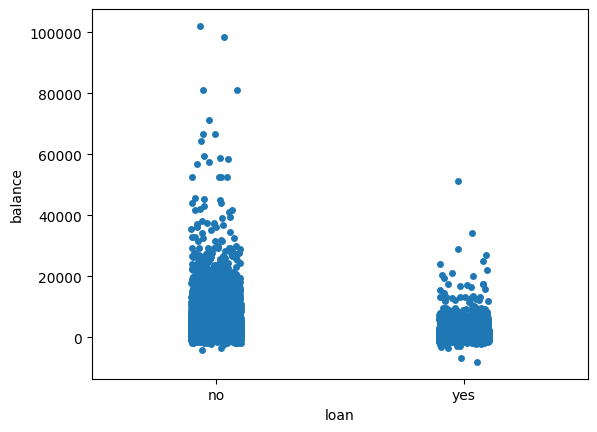

(0.0, 10000.0)

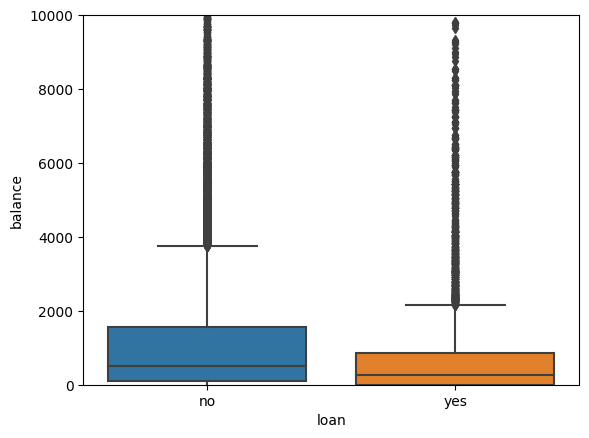

In [14]:
ax = sns.stripplot(x="loan", y="balance", data=bank)
plt.ylabel('balance')
plt.show()
sns.boxplot(x="loan", y="balance", data=bank)
plt.ylim((0,10000))

Since the distribution of the data has heavy tails, it is hard to tell much from the strip plot whether there is a difference between the two subgroup means. We continue our data analysis by looking at summary statistics for each of the two groups:

In [15]:
bank[bank.loan=="yes"].balance.describe()

count     7244.000000
mean       774.309912
std       1908.283253
min      -8019.000000
25%          2.000000
50%        258.000000
75%        864.250000
max      51439.000000
Name: balance, dtype: float64

In [16]:
bank[bank.loan=="no"].balance.describe()

count     37967.000000
mean       1474.453631
std        3204.088951
min       -4057.000000
25%          94.000000
50%         496.000000
75%        1558.000000
max      102127.000000
Name: balance, dtype: float64

### Are the means of the loan and no loan groups significantly different? (5 min)

We would like to test statistically whether the two group means are different from each other; that is, whether the difference between the mean balance in the groups with a loan ($\mu_1$) is different than the mean balance in the group with no loan ($\mu_2$). The testing procedure that we described can be used also to answer this question:
$$ H_0: \mu_1=\mu_2$$
$$H_a: \mu_1 \neq \mu_2$$

We get the following output:

In [17]:
loans=bank[bank.loan=="yes"].balance
no_loans=bank[bank.loan=="no"].balance

statistic, pvalue = stats.ttest_ind(loans,no_loans, equal_var=False)
statistic, pvalue

(-25.180860577557155, 2.764056477754413e-137)

### Question: (2 min)

What would you conclude from the above test?

**Answer:** The $p$ - value is very small (p = 2.76 e-1376); hence, we reject the null hypothesis that the two groups have the same mean.

### Differences by education (5 min)

In our search to determine what factors are important in customer segmentation, we can identify in this large dataset if education plays a role in customer behavior. The variable `education` has 4 categories:

In [18]:
bank["education"].unique()

array(['tertiary', 'secondary', 'unknown', 'primary'], dtype=object)

### Exercise 6: ( 3 min)

Below we have written code to plot the balance by education via a strip plot (i.e. grouped 1D scatterplot). From your visual exploration, do you think there is a difference across the groups? 

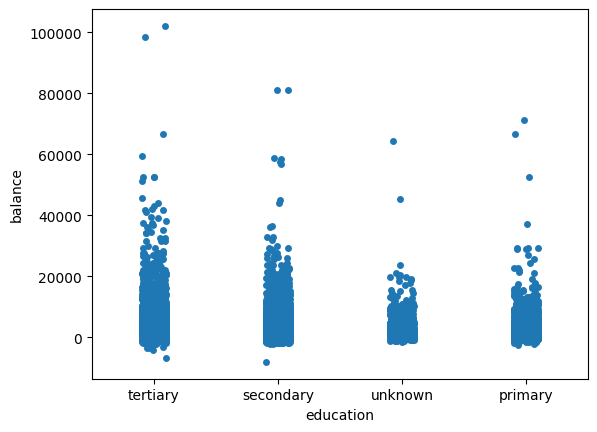

<AxesSubplot: xlabel='education', ylabel='balance'>

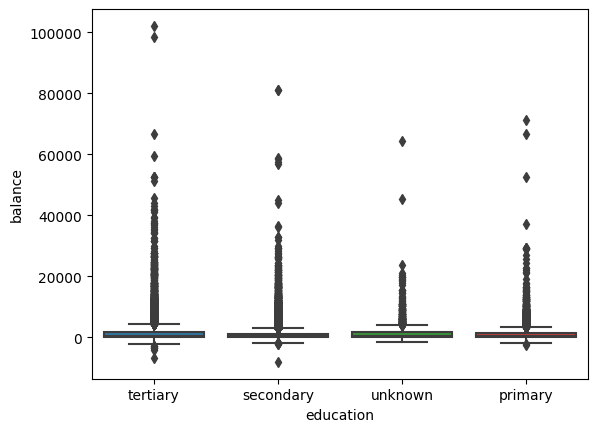

In [27]:
ax = sns.stripplot(x="education", y="balance", data=bank)
plt.ylabel('balance')
plt.show()
bank[['balance','education']].groupby('education').mean()
bank[['balance','education']].groupby('education').median()
sns.boxplot(x="education", y="balance", data=bank)
# plt.ylim((-1000,5000))


**Answer.** The standard visual representation in this case does not provide too much insight; thus, we need an alternative method to investigate further.

## Do bank balances differ significantly across education cohorts? (25 min)

Our new hypothesis will be:

$$ H_0: \mu_1=\mu_2=\mu_3=\mu_4$$
$$H_a : \mathrm{At \,least\, one\, of\, the\, means\,} \mu_j \mathrm{\,is \,different\, from\, the \,others}.$$

To test this hypothesis we need an extension of the capabilities of the $t$ - test (which can test only two groups at the same time). This test is called **Analysis of Variance (ANOVA)**.

In [25]:
mod = ols('balance ~ education', data=bank).fit()  
aov_table = sm.stats.anova_lm(mod, typ=2)
aov_table

,sum_sq,df,F,PR(>F)
education,3.220417e+09,3.0,116.682074,2.849538e-75
Residual,4.159034e+11,45207.0,NaN,NaN


As we can see, looking at the $p$ - value that accompanies the $F$ - statistics, we obtain a strong rejection of the null hypothesis, leading us to conclude that education groups have some differences in their means. The ANOVA test does not tell us which pair of groups have means that are different from each other. To investigate these differences further, we are going first to report the descriptive statistics by group, and then display the group means in a bar chart:

In [28]:
bank[bank.education=="primary"].balance.describe()

count     6851.000000
mean      1250.949934
std       2690.743991
min      -2604.000000
25%         61.000000
50%        403.000000
75%       1390.000000
max      71188.000000
Name: balance, dtype: float64

In [29]:
bank[bank.education=="secondary"].balance.describe()

count    23202.000000
mean      1154.880786
std       2558.256739
min      -8019.000000
25%         55.000000
50%        392.000000
75%       1234.000000
max      81204.000000
Name: balance, dtype: float64

In [30]:
bank[bank.education=="tertiary"].balance.describe()

count     13301.000000
mean       1758.416435
std        3839.088305
min       -6847.000000
25%         104.000000
50%         577.000000
75%        1804.000000
max      102127.000000
Name: balance, dtype: float64

In [31]:
bank[bank.education=="unknown"].balance.describe()

count     1857.000000
mean      1526.754443
std       3152.228273
min      -1445.000000
25%        106.000000
50%        568.000000
75%       1699.000000
max      64343.000000
Name: balance, dtype: float64

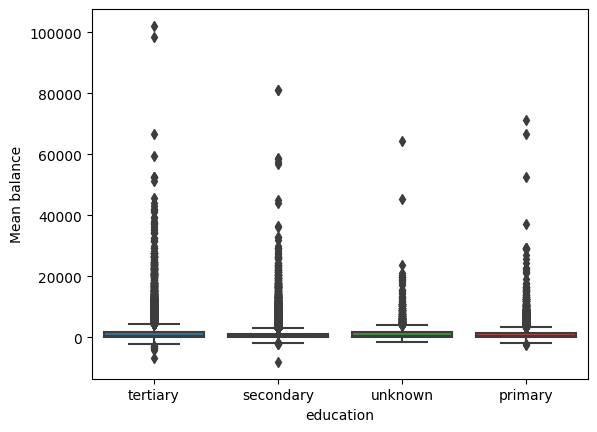

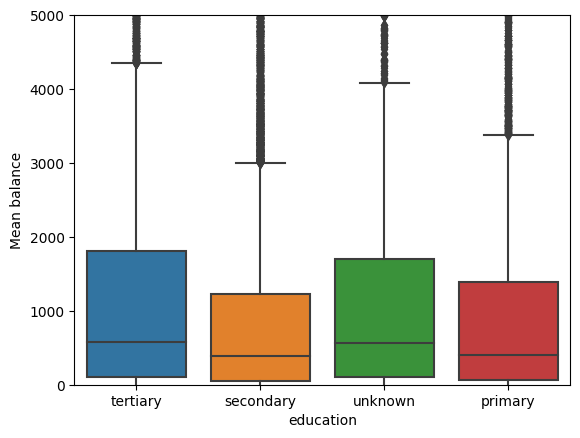

education
primary      1250.949934
secondary    1154.880786
tertiary     1758.416435
unknown      1526.754443
Name: balance, dtype: float64

In [32]:
mean_balance_education=bank.groupby(by="education").balance.mean()
sns.boxplot(x=bank.education, y=bank.balance)
plt.ylabel("Mean balance")
plt.show()
sns.boxplot(x=bank.education, y=bank.balance)
plt.ylabel("Mean balance")
plt.ylim((0,5000))
plt.show()
# sns.barplot(x=mean_balance_education.index, y=mean_balance_education.values, color="green")
# plt.ylabel("Mean balance")
# plt.show()
mean_balance_education

Qualitatively there seems to be a big difference between tertiary and lower education levels, but the difference between primary and secondary education groups is more difficult to assess. We want to test if there is a significant difference in each pairwise comparison. To test this sequence of hypotheses we can use a variant of the $t$ - test, called a **pairwise $t$ - test**.


In [33]:
gb = bank.groupby(['education'])
group_names = bank["education"].unique()
print("\t\t\tstatistic\t\tpvalue")
for i in range(len(group_names)):
    for j in range(i+1, len(group_names)):
        group1 = gb[["balance"]].get_group(group_names[i])
        group2 = gb[["balance"]].get_group(group_names[j])
        stat, pvalue = stats.ttest_ind(group1, group2, equal_var = False)
        print(group_names[i] + " vs. " + group_names[j] + "\t" + str(stat[0]) + "\t" + str(pvalue[0]))

			statistic		pvalue
tertiary vs. secondary	16.18717929985782	1.4525474790099814e-58
tertiary vs. unknown	2.882532183120312	0.003976238237673678
tertiary vs. primary	10.906634331433306	1.3023845080432283e-27
secondary vs. unknown	-4.954823286819341	7.831117109430851e-07
secondary vs. primary	-2.6255174227477864	0.0086639693661419
unknown vs. primary	3.4454969444009635	0.0005789323657180864


The summary output above signals that there is a significant difference between each pairwise comparison.


### Exercise 7: (4 min)

There are six comparisons in total that have to be conducted because the variable education has 4 levels. Discuss with a partner if, in your opinion, performing multiple tests simultaneously can increase the risk of erroneous inferences.
What will increase: Type I error or Type II error?

**Answer.** Yes, the more comparisons we run simultaneously, the higher the risk of observing some "false positives" or making a Type I error. Basically, if your torture the data enough, it will confess.

### Multiple comparisons: the Bonferroni correction (15 min)

There are many ways to correct this issue, known as the "multiple comparisons" problem. One of the most classical methods is the Bonferroni correction. This method divides the significance level $\alpha$ by the number of multiple comparisons being performed (6 in this case). So if our $\alpha=0.05$ we will reject the null hypothesis only if the $p$ - value is less than 0.00833.

Notice that the $p$ - value for the comparison between "primary" and "secondary" education is 0.02126, and therefore higher than the adjusted confidence level. After the correction we cannot reject the null hypothesis that this pair has significantly different means. Several software packages directly adjust the $p$ - values for the increased probability of observing a false positive. If we perform this method for `education`, we get the following output:

In [34]:
pairwise_results = pairwise_tests(dv='balance', between = ['education'], padjust='bonf', data=bank)
pairwise_results

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,education,primary,secondary,False,True,2.625517,10768.241876,two-sided,8.663969e-03,5.198382e-02,bonf,0.486,0.037105
1,education,primary,tertiary,False,True,-10.906634,18353.418018,two-sided,1.302385e-27,7.814307e-27,bonf,9.088e+23,-0.145344
2,education,primary,unknown,False,True,-3.445497,2633.681528,two-sided,5.789324e-04,3.473594e-03,bonf,10.941,-0.098651
3,education,secondary,tertiary,False,True,-16.187179,20183.403282,two-sided,1.452547e-58,8.715285e-58,bonf,5.742e+54,-0.195497
4,education,secondary,unknown,False,True,-4.954823,2056.380989,two-sided,7.831117e-07,4.698670e-06,bonf,5633.685,-0.142646
5,education,tertiary,unknown,False,True,2.882532,2688.204879,two-sided,3.976238e-03,2.385743e-02,bonf,1.76,0.061581


In the above table, ``p-unc`` stands for the uncorrected $p$ - value, and ``p-adjust`` stands for the corrected $p$ - value. The adjusted $p$ - value for "secondary vs. primary" is 0.052 (greater than 0.05), confiriming our calculation. We thus reject all of the null hypotheses except for the "secondary vs. primary" case.

### Exercise 8: (10 min)

Perform an exploratory data analysis of the bank balance by job title. Write code to answer the following two questions:

1. Are the group means the same? Write a hypothesis for this, clearly stating what $H_0$ is.
2. Do a pairwise hypothesis test for comparing the different group means, applying the Bonferroni correction.
3. Do you find any of the results of hypothesis tests of customers in management vs. other groups surprising?

**Answer.** One possible solution is given below:

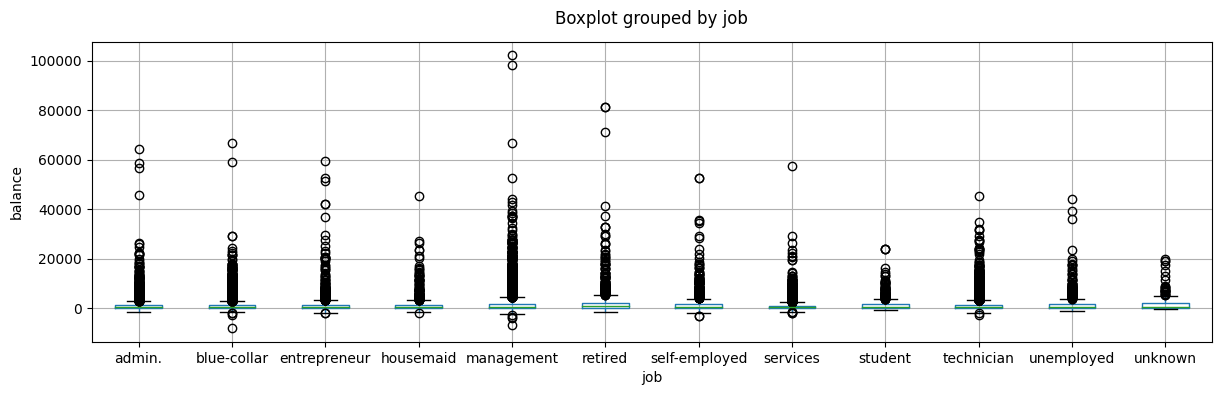

               balance
job                   
admin.           396.0
blue-collar      388.0
entrepreneur     352.0
housemaid        406.0
management       572.0
retired          787.0
self-employed    526.0
services         339.5
student          502.0
technician       421.0
unemployed       529.0
unknown          677.0


(0.0, 20000.0)

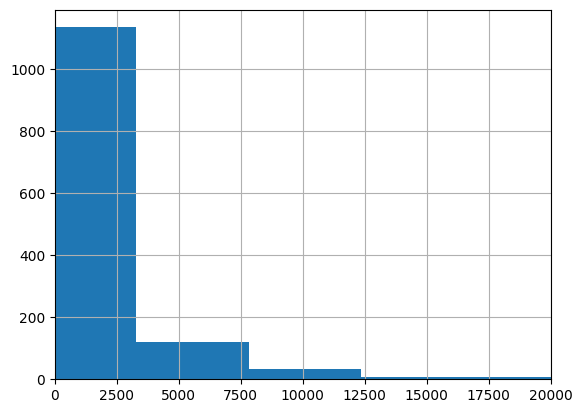

In [31]:
boxplot = bank.boxplot(column=['balance'], by="job",figsize=(14,4))
boxplot.axes.set_title("")
plt.ylabel('balance')
plt.show()
bank[['job','balance']].groupby('job').mean()
print(bank[['job','balance']].groupby('job').median())
bank.loc[bank['job']=="unemployed",'balance'].hist()
plt.xlim((0,20000))

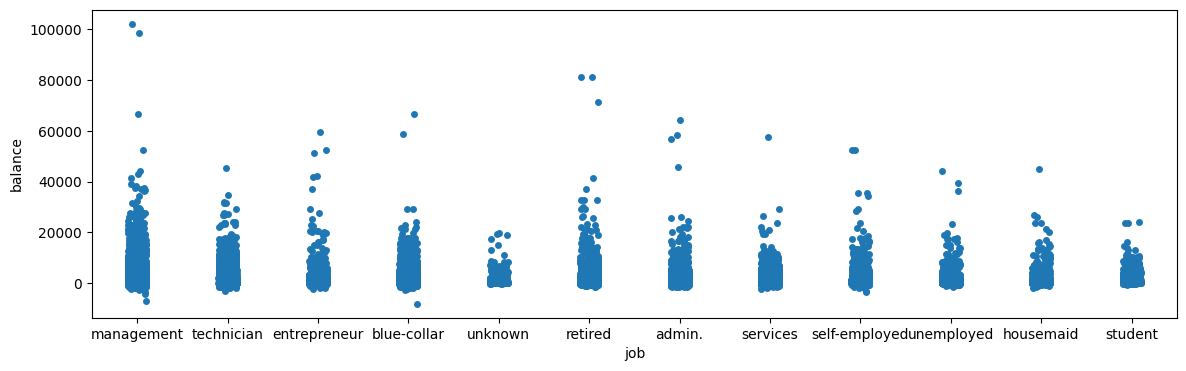

In [28]:
plt.figure(figsize=(14,4))
ax = sns.stripplot(x="job", y="balance", data=bank)
plt.ylabel('balance')
plt.show()

In [29]:
mod = ols('balance ~ job', data=bank).fit()  
aov_table = sm.stats.anova_lm(mod, typ=2)
aov_table

,sum_sq,df,F,PR(>F)
job,4.341414e+09,11.0,43.007783,5.709430e-94
Residual,4.147824e+11,45199.0,NaN,NaN


In [30]:
pairwise_job_results = pairwise_tests(dv='balance', between = ['job'], padjust='bonf', data=bank)
pairwise_job_results[pairwise_job_results['A']=='management']

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
38,job,management,retired,False,True,-2.196665,3131.535808,two-sided,2.811739e-02,1.000000e+00,bonf,0.293,-0.055981
39,job,management,self-employed,False,True,1.148353,2184.520136,two-sided,2.509488e-01,1.000000e+00,bonf,0.059,0.030404
40,job,management,services,False,True,14.825903,12787.547265,two-sided,2.556646e-49,1.687386e-47,bonf,4.105e+45,0.225194
41,job,management,student,False,True,4.225002,1439.557060,two-sided,2.539487e-05,1.676061e-03,bonf,276.437,0.100961
42,job,management,technician,False,True,10.429971,16520.443985,two-sided,2.169693e-25,1.431997e-23,bonf,5.845e+21,0.154074
43,job,management,unemployed,False,True,2.530687,1875.469495,two-sided,1.146511e-02,7.566972e-01,bonf,0.809,0.064539
44,job,management,unknown,False,True,-0.048726,316.659804,two-sided,9.611682e-01,1.000000e+00,bonf,0.067,-0.002300


The account balance of unemployed customers and management customers is not significantly different, and this is surprising...? Or is it?

## Conclusions (3 min)

After doing exploratory data analysis, we formally introduced hypothesis tests. We saw that education level definitely affects bank balance; customers with a tertiary education seem to have a statistically significant difference in bank balance compared to the rest of the population. However, after adjusting for multiple testing, there does not seem to be a statistically significant difference between customers with a primary and secondary education. We also saw quite a few statistically significant differences in the bank balances of customers with different job profiles.

## Takeaways (5 min)

In this case, we've taken the first steps from exploratory data analysis toward confirmatory analysis. We have:

1. Introduced the concept of hypothesis testing. This tool will help you with problems that involve the detection of differences across populations. Problems like this will be common in your work as a data scientist. 
2. Understood the importance of recognizing when changes in our data correspond to natural fluctuation or not, and how hypothesis testing can help us with this problem. 
3. Learned how to interpret the outcome of a hypothesis test using $p$-values. This concept appears in many models that are used in data science and we will see them in several future cases as well. 
4. Understood the risks of conducting multiple comparisons to the same data and a way to prevent these risks using the Bonferroni correction. Remember, "If we torture the data enough, it will confess."